# Phylogenetic trees Rhabdoid cohort

In [1]:
import json
import pandas as pd
import pybedtools
import matplotlib.pyplot as plt
import seaborn as sns

/home/msanchezg/miniconda3/envs/rhabdoids/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
chroms = list(range(1,23))
chroms = ['chr'+str(chrom) for chrom in chroms]
sex_chroms = ['chrX','chrY']
chroms = chroms + sex_chroms
pts = ['pt1','pt3','pt4','pt5','pt6','pt9','pt12','pt14','pt18','PMC01']
sjd_dict = json.load(open('sample_ids/sample_sjd_ids.json','rb'))
sjd_ccf =json.load(open( "ccf_thresholds/ccf_thresholds_sjd.json", "rb" ) )
pmc_dict = json.load(open('sample_ids/sample_pmc_ids.json','rb'))
pmc_ccf =json.load(open( "ccf_thresholds/ccf_thresholds_pmc_case.json", "rb" ) )
samples_dict = sjd_dict | pmc_dict
ccf_thresholds = sjd_ccf | pmc_ccf
samples_final_ids_dict = json.load(open("sample_ids/sample_ids_final.json", "rb"))

In [4]:
samples_dict
samples_final_ids_dict

{'pt18': 'PT01',
 'pt4': 'PT02',
 'pt13': 'PT03',
 'PAUDPV': 'PT04',
 'SJ032417': 'PT05',
 'PAJNER': 'PT06',
 'PASWZZ': 'PT07',
 'PAVYKD': 'PT08',
 'PATXKA': 'PT09',
 'PARECB': 'PT10',
 'PASVDP': 'PT11',
 'PAJMBW': 'PT12',
 'PATDVL': 'PT13',
 'PARGRN': 'PT14',
 'SJ034089': 'PT15',
 'PAVYDM': 'PT16',
 'PASABD': 'PT17',
 'PAEHIP': 'PT18',
 'pt9': 'PT19',
 'SJ030997': 'PT20',
 'PASYNF': 'PT21',
 'PARRCL': 'PT22',
 'PARUGK': 'PT23',
 'pt12': 'PT24',
 'PAWFWK': 'PT25',
 'PAUHAZ': 'PT26',
 'SJ031235': 'PT27',
 'SJ034110': 'PT28',
 'PARTKH': 'PT29',
 'PASADZ': 'PT30',
 'SJ033236': 'PT31',
 'PAUCGJ': 'PT32',
 'PASXNA': 'PT33',
 'PAJLWM': 'PT34',
 'PASRHU': 'PT35',
 'PAREWI': 'PT36',
 'PASZYE': 'PT37',
 'PASDLA': 'PT38',
 'PATAFT': 'PT39',
 'PAJNFP': 'PT40',
 'PASCDH': 'PT41',
 'PARPFY': 'PT42',
 'SJ015723': 'PT43',
 'PADWRZ': 'PT44',
 'PATFZZ': 'PT45',
 'PABKLN': 'PT46',
 'pt19': 'PT47',
 'SJ030128': 'PT48',
 'PAUGYZ': 'PT49',
 'PARZBI': 'PT50',
 'PAKLYZ': 'PT51',
 'PAJMRB': 'PT52',
 'pt6': 'P

In [5]:
def prepare_table(pt1_t1_mutect_df,pt1_t2_mutect_df,snv):
    df1 = pt1_t1_mutect_df[['#CHROM','POS','REF','ALT','t_CCF','mut_type']]
    df1.drop_duplicates(subset=['#CHROM','POS','REF','ALT'],keep='first',inplace=True)
    df2 = pt1_t2_mutect_df[['#CHROM','POS','REF','ALT','t_CCF','mut_type']]
    df2.drop_duplicates(subset=['#CHROM','POS','REF','ALT'],keep='first',inplace=True)
    t1_t2_df = pd.merge(df1,df2,on=['#CHROM','POS','REF','ALT','mut_type'], how='outer',indicator='tumor', suffixes=('_t1','_t2'))
    t1_t2_df['tumor'] = t1_t2_df['tumor'].replace('left_only','T1')
    t1_t2_df['tumor'] = t1_t2_df['tumor'].replace('right_only','T2')
    if snv == True:
        t1_t2_df = t1_t2_df[t1_t2_df['mut_type']=='snv']
#     t1_t2_df = t1_t2_df.drop(columns=['mut_type'])
    return t1_t2_df

## Include age, ttmt status and tumor location info

In [6]:
samples_dict2 = {samples_dict[pt][t]:t for pt in samples_dict.keys() for t in samples_dict[pt].keys() }
samples_dict2

{'AX4894': 'normal',
 'AX4912': 'tumor1',
 'AX4937': 'tumor2',
 'male': 'sex',
 'AX4895': 'normal',
 'AX4914': 'tumor1',
 'AX4915': 'tumor2',
 'AX4946': 'clone1',
 'AX4947': 'clone2',
 'AX4896': 'normal',
 'AX4916': 'tumor1',
 'AX4938': 'tumor2',
 'female': 'sex',
 'AX4897': 'normal',
 'AX4918': 'tumor1',
 'AX4944': 'tumor2',
 'AX4898': 'normal',
 'AX4945': 'tumor1',
 'AX4921': 'tumor2',
 'AX4942': 'clone1',
 'AX4943': 'clone2',
 'AX4899': 'normal',
 'AX4922': 'tumor1',
 'AX4900': 'normal',
 'AX4930': 'tumor1',
 'AX4901': 'normal',
 'AX4924': 'tumor1',
 'AX4925': 'tumor2',
 'AX4903': 'normal',
 'AX4951': 'tumor1',
 'AX4904': 'normal',
 'AX4926': 'tumor1',
 'AX4940': 'tumor2',
 'AX4905': 'normal',
 'AX4927': 'tumor1',
 'AQ5174': 'normal',
 'AX4928': 'tumor1',
 'AX4929': 'tumor2',
 'AX4958': 'clone1',
 'AX4961': 'clone2',
 'AX4906': 'normal',
 'AX4923': 'tumor1',
 'AX4907': 'normal',
 'AX4931': 'tumor1',
 'AX4908': 'normal',
 'AX4932': 'tumor1',
 'AX4909': 'normal',
 'AX4933': 'tumor1',


In [7]:
paired_pts = [pt for pt in samples_dict.keys() if 'tumor2' in samples_dict[pt].keys() and pt not in ['pt9','pt12','pt14']]
paired_pts

['pt1', 'pt3', 'pt4', 'pt5', 'pt6', 'pt18', 'PMC01']

In [31]:
tab_dict = json.load(open('clinical_data/tab_dict.json','rb'))
tab_dict

{'pt1_t1': 8.32,
 'pt1_t2': 8.56,
 'pt3_t1': 4.79,
 'pt3_t2': 6.16,
 'pt4_t1': 0.02,
 'pt4_t2': 0.03,
 'pt5_t1': 13.5,
 'pt5_t2': 13.7,
 'pt6_t1': 1.6,
 'pt6_t2': 1.64,
 'pt7_t1': 2.25,
 'pt8_t1': 3.02,
 'pt9_t1': 0.44,
 'pt9_t2': 0.49,
 'pt11_t1': 5.57,
 'pt12_t1': 0.68,
 'pt12_t2': 0.68,
 'pt13_t1': 0.53,
 'pt14_t1': 10.1,
 'pt14_t2': 10.5,
 'pt15_t1': 15.58,
 'pt16_t1': 1.67,
 'pt17_t1': 2.61,
 'pt18_t1': 0.01,
 'pt18_t2': 0.02,
 'pt19_t1': 1.13,
 'pt20_t1': 0.57,
 'PABKLN': 1.1,
 'PADWRZ': 1.05,
 'PADYCE': 2.28,
 'PADYZI': 2.97,
 'PAEHIP': 0.48,
 'PAJLRA': 0.01,
 'PAJLWM': 0.79,
 'PAJMBW': 0.39,
 'PAJMRB': 1.48,
 'PAJNER': 0.17,
 'PAJNFP': 0.96,
 'PAJNFZ': 1.62,
 'PAJPHJ': 0.95,
 'PAKHTL': 3.13,
 'PAKLYZ': 1.44,
 'PAKPEW': 2.6,
 'PAKTCT': 2.36,
 'PARECB': 0.38,
 'PAREWI': 0.84,
 'PARGRN': 0.4,
 'PARIRN': 4.02,
 'PARKKN': 6.45,
 'PARPFY': 0.99,
 'PARRCL': 0.59,
 'PARTKH': 0.73,
 'PARUGK': 0.6,
 'PARZBI': 1.44,
 'PARZRH': 1.67,
 'PASABD': 0.47,
 'PASADZ': 0.75,
 'PASAMZ': 8.29,
 'PAS

In [9]:
tab_t1_dict = {k:v for k,v in tab_dict.items() if k.endswith('_t1')}
tab_paired_dict = {sample:tab_dict[sample] for sample in tab_t1_dict.keys() if sample.split('_')[0] in paired_pts}
sorted_tab_paired_dict = {k: v for k, v in sorted(tab_paired_dict.items(), key=lambda item: item[1])}
sorted_paired_pts = list(dict.fromkeys([ sample.split('_')[0] for sample in sorted_tab_paired_dict.keys()]))
sorted_paired_pts

['pt18', 'pt4', 'pt6', 'PMC01', 'pt3', 'pt1', 'pt5']

In [10]:
clinical_df = pd.read_csv('clinical_data/SJD_clinical_data_patient.tsv',sep='\t')
clinical_df.columns

Index(['PATIENT_ID', 'GENDER', 'TUMOR_TYPE', 'TAB_DIAGNOSIS', 'TREATMENT',
       'TAB_TTMT_START_DATE', 'TAB_TTMT_END_DATE', 'STATUS (Deceased/Alive)',
       'SAMPLE_AVAILABILITY', 'Diagnosis', 'Primary tumor',
       'Metastasis (at debut)', 'Site of relapse', 'Unnamed: 13'],
      dtype='object')

In [11]:
clinical_df = pd.read_csv('clinical_data/SJD_clinical_data_sample.tsv',sep='\t')
clinical_df = clinical_df[clinical_df['SAMPLE_TYPE']!='Normal blood']
clinical_df = clinical_df[~clinical_df['SAMPLE_ID'].isnull()]
clinical_df = clinical_df[~clinical_df['CNAG_CODE'].isin(['AX4913','AX4917','AX4919','AX4920'])]
clinical_df = clinical_df[['PATIENT_ID','SAMPLE_ID','CNAG_CODE','SAMPLE_TYPE','TAB_BIOPSY','TAB_YEAR','TAB_MONTH','TAB_DAYS','SAMPLE_LOCATION']]
clinical_df['PATIENT'] = clinical_df['PATIENT_ID'].apply(lambda x: 'pt'+str(x))
clinical_df['SAMPLE'] = clinical_df.apply(lambda row: row['PATIENT']+'_t'+samples_dict2[row['CNAG_CODE']][-1],axis=1)
clinical_df = clinical_df.sort_values(['PATIENT_ID','SAMPLE'],ascending=[True,True])
clinical_df

,PATIENT_ID,SAMPLE_ID,CNAG_CODE,SAMPLE_TYPE,TAB_BIOPSY,TAB_YEAR,TAB_MONTH,TAB_DAYS,SAMPLE_LOCATION,PATIENT,SAMPLE
21,1,1pre,AX4912,Tumor pre ttmt,8.32,8.0,3.00,NaN,Pelvis,pt1,pt1_t1
49,1,1post #2,AX4937,Tumor post ttmt,8.56,8.0,6.00,NaN,Retroperitoneum,pt1,pt1_t2
24,3,3pre,AX4914,Tumor pre ttmt,4.79,4.0,9.00,NaN,Kidney,pt3,pt3_t1
62,3,RT223_Clone2F11,AX4946,Cell line pre ttmt,4.79,4.0,9.00,NaN,NaN,pt3,pt3_t1
25,3,3post,AX4915,Tumor post ttmt,6.16,6.0,1.00,NaN,Lung,pt3,pt3_t2
63,3,RT223_Clone1G3,AX4947,Cell line pre ttmt,4.79,4.0,9.00,NaN,NaN,pt3,pt3_t2
26,4,4,AX4916,Tumor pre ttmt,0.02,0.0,0.24,7.0,Skin and soft tissue,pt4,pt4_t1
50,4,4necro #2,AX4938,Tumor pre ttmt,0.03,0.0,0.00,NaN,Skin and soft tissue,pt4,pt4_t2
28,5,5pre,AX4918,Tumor pre ttmt,13.50,13.0,6.00,NaN,Paraspinal,pt5,pt5_t1
60,5,5post,AX4944,Tumor post ttmt,13.70,13.0,8.00,NaN,NaN,pt5,pt5_t2


In [12]:
pmc_loc_dict = {'OMEN':'Omentum',
                'DIAF':'Diaphragm',
                'LN':'Lymph node',
                'LNMETA':'Lymph node'}

In [13]:
sample_code_dict = {''}

In [14]:
paired_df = clinical_df[clinical_df['PATIENT'].isin(pts)]
paired_df = paired_df.sort_values(['TAB_BIOPSY','PATIENT_ID'],ascending=[True,False])
paired_df['SAMPLE_LOCATION'] = paired_df['SAMPLE_LOCATION'].fillna('NA')
paired_df['SAMPLE_LOCATION'] = paired_df['SAMPLE_LOCATION'].replace('Soft tissue (multiple tumor masses)','Soft tissue')
paired_df['SAMPLE_TYPE'] = paired_df['SAMPLE_TYPE'].str.split('Tumor ',expand=True)[1]
paired_df = paired_df[~paired_df['SAMPLE_TYPE'].isnull()] # eliminate samples from clones
#add pmc case
for t in (t for t in samples_dict['PMC01'].keys() if t not in ['normal','normal2']):
    tumor_id = samples_dict['PMC01'][t]
    pmc_case_dict = {'PATIENT_ID':'PMC01',
                    'SAMPLE_ID':tumor_id,
                    'SAMPLE_TYPE':'post ttmt',
                    'TAB_BIOPSY':2.5,
                    'TAB_YEAR':2,
                    'TAB_MONTH':6,
                    'SAMPLE_LOCATION': pmc_loc_dict[tumor_id],
                    'PATIENT':'PMC01',
                    'SAMPLE':'PMC01_t'+t[-1]}
    paired_df = pd.concat([paired_df,pd.DataFrame([pmc_case_dict])])
paired_df = paired_df.sort_values(['TAB_BIOPSY','PATIENT_ID'],ascending=[True,False])
paired_df

,PATIENT_ID,SAMPLE_ID,CNAG_CODE,SAMPLE_TYPE,TAB_BIOPSY,TAB_YEAR,TAB_MONTH,TAB_DAYS,SAMPLE_LOCATION,PATIENT,SAMPLE
43,18,18,AX4933,pre ttmt,0.01,0.0,0.12,4.0,Soft tissue,pt18,pt18_t1
44,18,18necro,AX4934,pre ttmt,0.02,0.0,0.24,7.0,Soft tissue,pt18,pt18_t2
26,4,4,AX4916,pre ttmt,0.02,0.0,0.24,7.0,Skin and soft tissue,pt4,pt4_t1
50,4,4necro #2,AX4938,pre ttmt,0.03,0.0,0.00,NaN,Skin and soft tissue,pt4,pt4_t2
34,9,9pre,AX4924,pre ttmt,0.44,0.0,5.00,8.4,Liver,pt9,pt9_t1
35,9,9post,AX4925,post ttmt,0.49,0.0,5.00,26.4,Liver,pt9,pt9_t2
36,12,12post,AX4926,post ttmt,0.68,0.0,8.00,NaN,Armpit,pt12,pt12_t1
52,12,12post #2,AX4940,post ttmt,0.68,0.0,8.00,NaN,Armpit,pt12,pt12_t2
61,6,6post,AX4945,post ttmt,1.60,1.0,7.00,NaN,NA,pt6,pt6_t1
31,6,6necro,AX4921,post ttmt,1.64,1.0,7.00,20.4,Laterocervical region,pt6,pt6_t2


## Filter by the mappable genome

In [15]:
def prepare_muts (df,mapp_genome_df=pd.DataFrame(),clonality=None):
    df = df[df['mut_type']=='snv']
    if clonality == 'clonal':
        df = df[df['clonal']==True]
    elif clonality == 'subclonal':
        df = df[df['clonal']==False]
    # print(len(df),'mutations intersect')
    df = df[df['gnomADg_AF']<0.001]
    # print(len(df), 'mutations after filtering gnomAD SNPs >0.001')

    #filter out mutations from low mappability regions with pybedtools intersect with the mappable genome
    df['POS2'] = df['POS'] + 1
    df = df[['#CHROM','POS','POS2','REF','ALT','FILTER']]
    if len(mapp_genome_df) != 0:
        mappgen_bt = pybedtools.BedTool.from_dataframe(mapp_genome_df)
        snvs_bt = pybedtools.BedTool.from_dataframe(df)
        mappgen_and_snvs = snvs_bt.intersect(mappgen_bt)
        snvs_mappgen_df = mappgen_and_snvs.to_dataframe()
        if len(snvs_mappgen_df) == 0:
            snvs_mappgen_df = pd.DataFrame(columns=['#CHROM','POS','FILTER','REF','ALT'])
        else:
            snvs_mappgen_df = snvs_mappgen_df.rename(columns={'chrom':'#CHROM','start':'POS','end':'POS2',
                                                             'name':'REF','score':'ALT','strand':'FILTER'})
            snvs_mappgen_df = snvs_mappgen_df.drop(columns=['POS2'])

        # print(len(snvs_mappgen_df), 'mutations after filtering regions with low mappability')
        df_out = snvs_mappgen_df.copy()
    else:
        df_out = df.copy()
    
    return df_out

mapp_genome_df = pd.read_csv('mappable_genome/hg38_100bp.coverage.regions.filtered_blacklisted.gz',sep='\t')
mapp_genome_df

,CHR,START,END
0,chr1,800910,800916
1,chr1,802489,802502
2,chr1,811249,811276
3,chr1,817177,817381
4,chr1,818744,818840
...,...,...,...
886926,chrY,26635237,26635834
886927,chrY,26635942,26636036
886928,chrY,26636383,26636592
886929,chrY,26636850,26637108


In [16]:
import matplotlib.gridspec as gridspec

In [32]:
sorted_pmc_samples = ['DIAF','OMEN','LNMETA','LN']

def prepare_pmc_table (pt='PMC01',samples=sorted_pmc_samples):
    normal_id = 'BLOOD'

    df = pd.DataFrame(columns=['#CHROM','POS','REF','ALT','mut_type'])
    for sample in samples:
        tumor_id = sample

        t1_df = pd.read_csv('mafs/mafs_pmc/'
                    +pt+'/'+tumor_id+'_vs_'+normal_id+'/filter_and_annot/'
                    +tumor_id+'_vs_'+normal_id+'_filt.maf.gz',sep='\t')

        t1_df = t1_df[t1_df['gnomADg_AF']<0.001]

        t1_df = t1_df[t1_df['clonal']==True]

        t1_df = t1_df[t1_df['mut_type']=='snv']
        
        t1_df = t1_df[['#CHROM','POS','REF','ALT','FILTER','t_CCF','mut_type','clonal']]
        t1_df.drop_duplicates(subset=['#CHROM','POS','REF','ALT'],keep='first',inplace=True)
        t1_df = t1_df[t1_df['mut_type']=='snv']
        
        #filter out mutations from low mappability regions with pybedtools intersect with the mappable genome
        t1_df['POS2'] = t1_df['POS'] + 1
        t1_df = t1_df[['#CHROM','POS','POS2','REF','ALT','FILTER','t_CCF','mut_type','clonal']]
        
        mappgen_bt = pybedtools.BedTool.from_dataframe(mapp_genome_df)
        snvs_bt = pybedtools.BedTool.from_dataframe(t1_df)
        mappgen_and_snvs = snvs_bt.intersect(mappgen_bt)
        snvs_mappgen_df = mappgen_and_snvs.to_dataframe()
        if len(snvs_mappgen_df) == 0:
            snvs_mappgen_df = pd.DataFrame(columns=['#CHROM','POS','FILTER','REF','ALT'])
        else:
            snvs_mappgen_df = snvs_mappgen_df.rename(columns={'chrom':'#CHROM','start':'POS','end':'POS2',
                                                                'name':'REF','score':'ALT','strand':'FILTER',
                                                                'thickStart':'t_CCF','thickEnd':'mut_type','itemRgb':'clonal'})
            snvs_mappgen_df = snvs_mappgen_df.drop(columns=['POS2','FILTER','mut_type'])

        # print(len(snvs_mappgen_df), 'mutations after filtering regions with low mappability')
        t1_df = snvs_mappgen_df.copy()


        df = pd.merge(df,t1_df,on=['#CHROM','POS','REF','ALT'], how='outer',indicator=sample)
        
        df = df.rename(columns={'t_CCF':'t_CCF_'+sample,
                                'clonal':'clonal_'+sample})
        
        df[sample] = df[sample].replace('left_only',False)
        df[sample] = df[sample].replace('both',True)
        df[sample] = df[sample].replace('right_only',True)

        # df = prepare_table(t1_df,df,snv=True)
        title = pt
        labels = None
    df[samples] = df[samples].fillna(False)
    t_ccf_cols = ['t_CCF_'+sample for sample in samples]
    df[t_ccf_cols] = df[t_ccf_cols].fillna(0.0)
    return df

df = prepare_pmc_table('PMC01',sorted_pmc_samples)

In [33]:
sorted_paired_pts

['pt18', 'pt4', 'pt6', 'PMC01', 'pt3', 'pt1', 'pt5']

/tmp/ipykernel_2526376/1898064825.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop_duplicates(subset=['#CHROM','POS','REF','ALT'],keep='first',inplace=True)
/tmp/ipykernel_2526376/1898064825.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop_duplicates(subset=['#CHROM','POS','REF','ALT'],keep='first',inplace=True)
/tmp/ipykernel_2526376/1898064825.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop_duplic

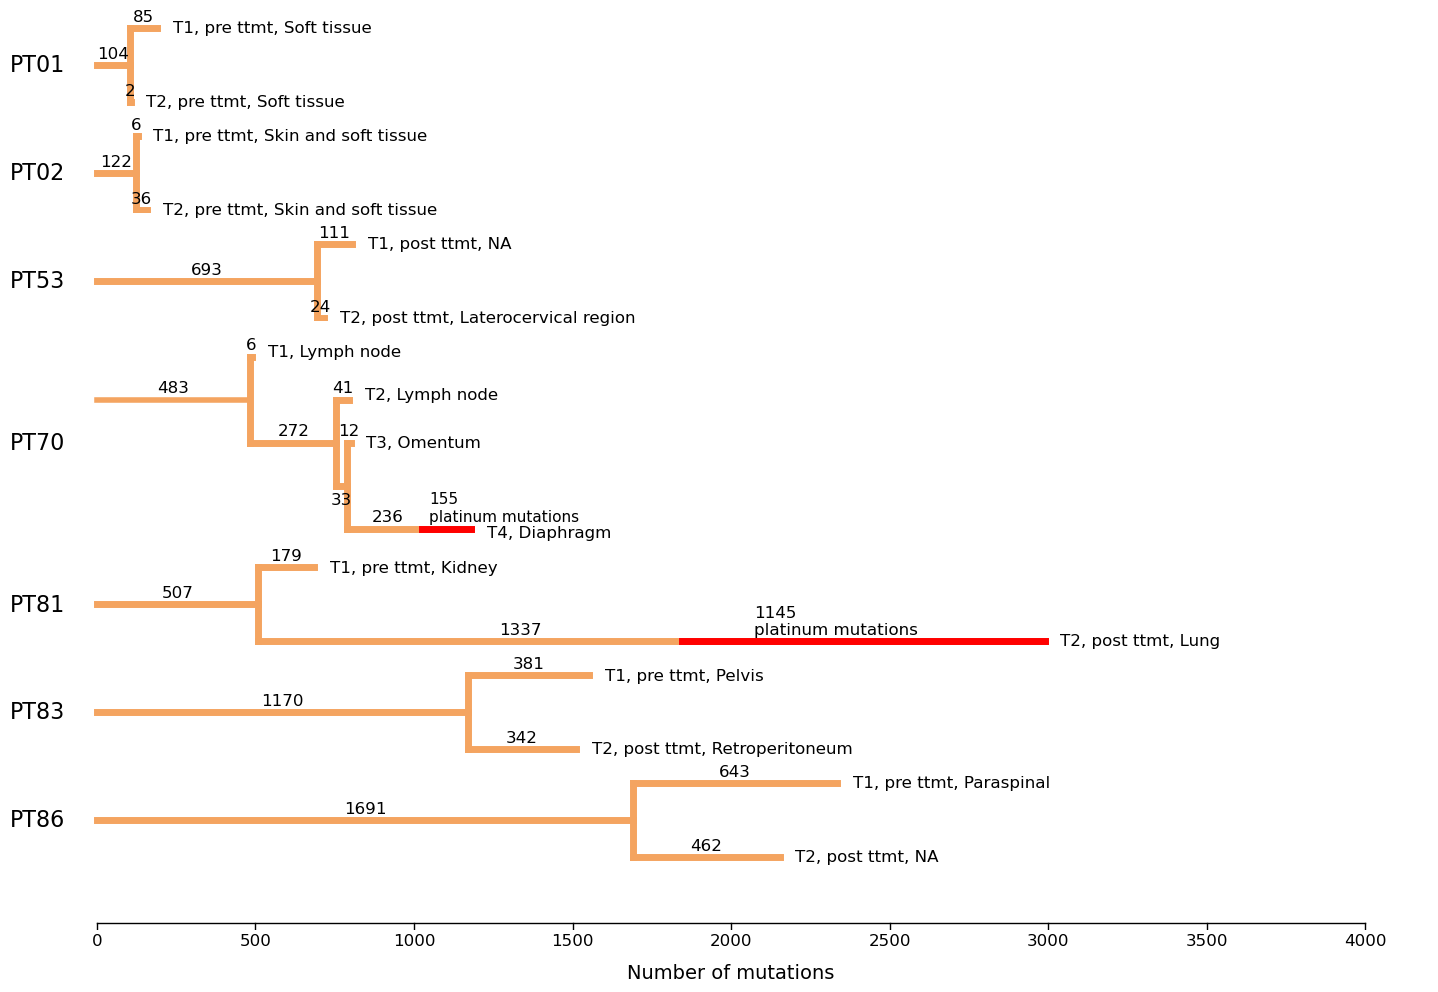

In [35]:
#filtered by mappable genome
sample = 'pt3_t2'
pt3_t2_df = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/clonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
platinum_muts_pt3 = pt3_t2_df['SBS35'][0]
sample = 'PMC01_t1'
pmc01_t1_df = pd.read_csv('signature_analysis/sigprofiler/fitting/results/'+sample+'/clonal/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',sep='\t')
platinum_muts_pmc = pmc01_t1_df['SBS31'][0]

common_dict = {}

fig = plt.figure(figsize=(18,12), dpi=100)
gs = gridspec.GridSpec(len(sorted_paired_pts)+3,1, hspace=0.4,height_ratios=[1]*(len(sorted_paired_pts)+1)+[0.1]*2)

n = 0

for pt in sorted_paired_pts:
    if pt == 'PMC01':
        muts_all = len(df[(df['DIAF']==True)&(df['OMEN']==True)&(df['LNMETA']==True)&(df['LN']==True)])
        muts_diaf_omen_lnmeta = len(df[(df['DIAF']==True)&(df['OMEN']==True)&(df['LNMETA']==True)&(df['LN']==False)])
        muts_diaf_omen = len(df[(df['DIAF']==True)&(df['OMEN']==True)&(df['LNMETA']==False)&(df['LN']==False)])
        muts_diaf = len(df[(df['DIAF']==True)&(df['OMEN']==False)&(df['LNMETA']==False)&(df['LN']==False)])
        muts_omen = len(df[(df['DIAF']==False)&(df['OMEN']==True)&(df['LNMETA']==False)&(df['LN']==False)])
        muts_lnmeta = len(df[(df['DIAF']==False)&(df['OMEN']==False)&(df['LNMETA']==True)&(df['LN']==False)])
        muts_ln = len(df[(df['DIAF']==False)&(df['OMEN']==True)&(df['LNMETA']==False)&(df['LN']==True)])
        
        #create a dict with common lineage muts
        
        common_dict[pt] = muts_all
        
        ax = fig.add_subplot(gs[n:n+2,0],sharex=ax)
        
        ax.plot([0,muts_all],[1,1],color='sandybrown',linewidth=4) #Line main trunk
        ax.plot([muts_all,muts_all+muts_diaf_omen_lnmeta],[0,0],color='sandybrown',linewidth=5) #Line diaf omen lnmeta trunk
        ax.plot([muts_all+muts_diaf_omen_lnmeta,muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen],[-1,-1],color='sandybrown',linewidth=5) #Line diaf omen trunk

        ax.plot([muts_all,muts_all+muts_ln],[2,2],color='sandybrown',linewidth=5) #Line LN
        ax.plot([muts_all+muts_diaf_omen_lnmeta,muts_all+muts_diaf_omen_lnmeta+muts_lnmeta],[1,1],color='sandybrown',linewidth=5) #Line lnmeta
        ax.plot([muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen,muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen+muts_omen],[0,0],color='sandybrown',linewidth=5) #Line OMEN
        ax.plot([muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen,muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen+muts_diaf],[-2,-2],color='sandybrown',linewidth=5) #Line DIAF
        
        ax.plot([muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen+muts_diaf-platinum_muts_pmc,muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen+muts_diaf],[-2,-2],color='red',linewidth=5) #Line DIAF platinum

        ax.plot([muts_all,muts_all],[2,0],color='sandybrown',linewidth=5)#Line both
        ax.plot([muts_all+muts_diaf_omen_lnmeta,muts_all+muts_diaf_omen_lnmeta],[1,-1],color='sandybrown',linewidth=5) #Line both
        ax.plot([muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen,muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen],[0,-2],color='sandybrown',linewidth=5) #Line both

        ax.text(x=(muts_all+muts_ln)+50,y=2.1,s='T1, '+pmc_loc_dict['LN'],fontsize=12,va='center') #Text LN
        ax.text(x=(muts_all+muts_diaf_omen_lnmeta+muts_lnmeta)+50,y=1.1,s='T2, '+pmc_loc_dict['LNMETA'],fontsize=12,va='center') #Text LNMETA
        ax.text(x=(muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen+muts_omen)+50,y=0,s='T3, '+pmc_loc_dict['OMEN'],fontsize=12,va='center') #Text OMEN
        ax.text(x=(muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen+muts_diaf)+50,y=-2.1,s='T4, '+ pmc_loc_dict['DIAF'],fontsize=12,va='center') #Text DIAF

        ax.text(x=(muts_all)/2,y=1.1,s=muts_all,fontsize=12,ha='center',va='bottom') # Number of mutations main trunk
        ax.text(x=muts_all+(muts_diaf_omen_lnmeta)/2,y=0.1,s=muts_diaf_omen_lnmeta,fontsize=12,ha='center',va='bottom') # Number of mutations diaf omen lnmeta trunk
        ax.text(x=muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen/2,y=-1.5,s=muts_diaf_omen,fontsize=12,ha='center',va='bottom') # Number of mutations diaf omen trunk
        ax.text(x=muts_all+muts_ln/2,y=2.1,s=muts_ln,fontsize=12,ha='center',va='bottom') #Number of mutations LN
        ax.text(x=(muts_all+muts_diaf_omen_lnmeta+muts_lnmeta/2),y=1.1,s=muts_lnmeta,fontsize=12,ha='center',va='bottom') #Number of mutations LNMETA
        ax.text(x=(muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen+muts_omen/2),y=0.1,s=muts_omen,fontsize=12,ha='center',va='bottom') #Number of mutations OMEN
        ax.text(x=(muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen+muts_diaf/3),y=-1.9,s=muts_diaf-platinum_muts_pmc,fontsize=12,ha='center',va='bottom') #Number of mutations DIAF

        ax.text(x=(muts_all+muts_diaf_omen_lnmeta+muts_diaf_omen+muts_diaf/3*2),y=-1.9,s=str(platinum_muts_pmc)+'\nplatinum mutations',fontsize=11,ha='left',va='bottom') #Number of mutations DIAF platinum

        title = samples_final_ids_dict[pt]
        
        ax.text(x=-100,y=0,s=title,fontsize=16,ha='right',va='center') #Title
        
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        plt.xticks([]) 
        plt.yticks([])

        ax1 = plt.axes(frameon=False)
        ax1.axes.get_yaxis().set_visible(False)
        ax1.axes.get_xaxis().set_visible(False)
        
        n = n +2

    else:
        normal_id = samples_dict[pt]['normal']
        tumor_id = samples_dict[pt]['tumor1']

        t1_df = pd.read_csv('mafs/mafs_sjd/'
                    +pt+'/'+tumor_id+'_vs_'+normal_id+'/filter_and_annot/'
                    +tumor_id+'_vs_'+normal_id+'_filt.maf.gz',sep='\t')
        

        tumor_id = samples_dict[pt]['tumor2']

        t2_df = pd.read_csv('mafs/mafs_sjd/'
                    +pt+'/'+tumor_id+'_vs_'+normal_id+'/filter_and_annot/'
                    +tumor_id+'_vs_'+normal_id+'_filt.maf.gz',sep='\t')
        
        subset = 'clonal'
        t11_df = prepare_muts (t1_df,mapp_genome_df,clonality=subset)
        t1_df = pd.merge(t11_df,t1_df,how='left')
        t22_df = prepare_muts (t2_df,mapp_genome_df,clonality=subset)
        t2_df = pd.merge(t22_df,t2_df,how='left')
                
        t1_t2_df = prepare_table(t1_df,t2_df,snv=True)
        title = pt
        labels = None
        plot_guide = True
        platinum=True
        
        if n != 0:
            ax = fig.add_subplot(gs[n,0],sharex=ax)
        else:
            ax = ax = fig.add_subplot(gs[n,0])
        
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        
        ax.set_xticks([]) 
        ax.set_yticks([])

        muts_both = len(t1_t2_df[t1_t2_df['tumor']=='both'])
        muts_t1 = len(t1_t2_df[t1_t2_df['tumor']=='T1'])
        muts_t2 = len(t1_t2_df[t1_t2_df['tumor']=='T2'])
    #     if pt == 'pt3':
    #         muts_t2 = muts_t2 - 883 #substract platinum muts
        common_dict[pt] = muts_both
        
        if labels !=None:
            tumor1 = labels[0]
            tumor2 = labels[1]
        else:
            tumor1 = 'T1'
            tumor2 = 'T2'    

        ttmt_t1 = paired_df['SAMPLE_TYPE'][paired_df['SAMPLE']==pt+'_t1'].iloc[0]
        ttmt_t2 = paired_df['SAMPLE_TYPE'][paired_df['SAMPLE']==pt+'_t2'].iloc[0]
        
        loc_t1 = paired_df['SAMPLE_LOCATION'][paired_df['SAMPLE']==pt+'_t1'].iloc[0]
        loc_t2 = paired_df['SAMPLE_LOCATION'][paired_df['SAMPLE']==pt+'_t2'].iloc[0]   
        
        ax.plot([muts_both,muts_both+muts_t1],[1,1],color='sandybrown',linewidth=5) #Line T1
        ax.plot([muts_both,muts_both+muts_t2],[-1,-1],color='sandybrown',linewidth=5) #Line T2
        ax.plot([0,muts_both],[0,0],color='sandybrown',linewidth=5) #Line both
        ax.plot([muts_both,muts_both],[1,-1],color='sandybrown',linewidth=5) #Line both
        if pt == 'pt3' and platinum == True:
            ax.plot([muts_both+muts_t2-platinum_muts_pt3,muts_both+muts_t2],[-1,-1],color='red',linewidth=5) #Line T2
            ax.text(x=(muts_both-platinum_muts_pt3*0.8+muts_t2),y=-0.9,s=str(platinum_muts_pt3)+'\nplatinum mutations',fontsize=12,ha='left',va='bottom') #Number of mutations T2
        
        ax.text(x=(muts_both+muts_t1)+50,y=1,s=tumor1+', '+ttmt_t1+', '+loc_t1,fontsize=12,va='center') #Text Tumor 1
        ax.text(x=(muts_both+muts_t2)+50,y=-1,s=tumor2+', '+ttmt_t2+', '+loc_t2,fontsize=12,va='center') #Text Tumor 2
        ax.text(x=(muts_both)/2,y=0.1,s=muts_both,fontsize=12,ha='center',va='bottom') # Number of mutations both
        ax.text(x=(muts_both+muts_t1/2),y=1.1,s=muts_t1,fontsize=12,ha='center',va='bottom') #Number of mutations T1
        if pt == 'pt3':
            ax.text(x=(muts_both+muts_t2/3),y=-0.9,s=muts_t2-platinum_muts_pt3,fontsize=12,ha='center',va='bottom') #Number of mutations T2
        else:
            ax.text(x=(muts_both+muts_t2/2),y=-0.9,s=muts_t2,fontsize=12,ha='center',va='bottom') #Number of mutations T2   
        
        title = samples_final_ids_dict[pt]

        ax.text(x=-100,y=0,s=title,fontsize=16,ha='right',va='center') #Title
            
        n = n+1


#plot guide mutations
ax = fig.add_subplot(gs[n+1,0],sharex=ax)
ax.plot([0,4000],[-2,-2],color='k',linewidth=1)
ax.text(2000,-3.5,s='Number of mutations',ha='center',size=14)
for x in range(0,4001,500):
    ax.plot([x,x],[-2,-2.2],color='k',linewidth=1)

    ax.text(x=x,y=-2.5,s=str(x),fontsize=12,va='center',ha='center') #Text Tumor 1
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_yticks([]) 
plt.savefig('plots/phylogenetic_trees.svg', bbox_inches='tight',format='svg')

In [20]:
paired_pts

['pt1', 'pt3', 'pt4', 'pt5', 'pt6', 'pt18', 'PMC01']

In [21]:
paired_df['PATIENT'].drop_duplicates()

43     pt18
26      pt4
34      pt9
36     pt12
61      pt6
0     PMC01
24      pt3
21      pt1
38     pt14
28      pt5
Name: PATIENT, dtype: object

In [22]:
sorted_paired_pts

['pt18', 'pt4', 'pt6', 'PMC01', 'pt3', 'pt1', 'pt5']

In [23]:
paired_df['TAB_BIOPSY'][paired_df['SAMPLE']==pt+'_t1']

28    13.5
Name: TAB_BIOPSY, dtype: float64

In [24]:
import matplotlib.patches as patches

/tmp/ipykernel_2526376/1770579400.py:38: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  age_t1 = float(paired_df['TAB_BIOPSY'][paired_df['SAMPLE']==pt+'_t1'])
/tmp/ipykernel_2526376/1770579400.py:39: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  age_t2 = float(paired_df['TAB_BIOPSY'][paired_df['SAMPLE']==pt+'_t2'])
/tmp/ipykernel_2526376/1770579400.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  age_t1 = float(paired_df['TAB_BIOPSY'][paired_df['SAMPLE']==pt+'_t1'])


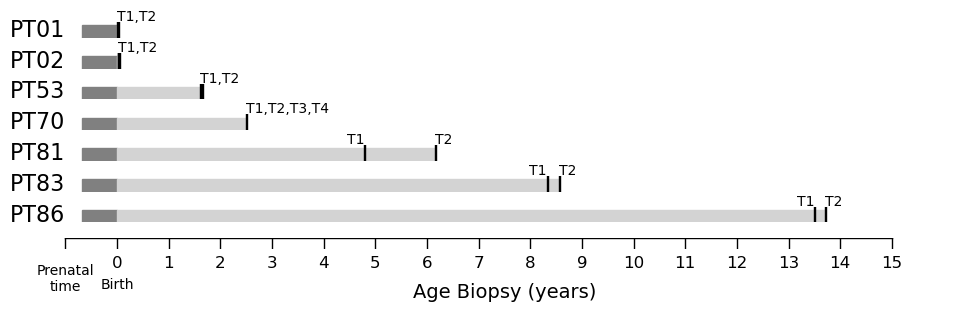

In [25]:
fig = plt.figure(figsize=(12,3), dpi=100)
gs = gridspec.GridSpec(len(paired_pts)+1,1, hspace=1,height_ratios=[1]*len(paired_pts)+[0.7])

for n, pt in enumerate(sorted_paired_pts):
    title = pt
    labels = None
    plot_guide = True
    platinum=True
    
    if n != 0:
        ax = fig.add_subplot(gs[n,0],sharex=ax)
    else:
        ax = ax = fig.add_subplot(gs[n,0])
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    ax.set_xticks([]) 
    ax.set_yticks([])
    ax.set_xlim(-2,16)
    ax.set_ylim(0,1)
    
    if pt == 'PMC01':
        age_t1 = float(paired_df['TAB_BIOPSY'][paired_df['SAMPLE']==pt+'_t1'])
        
        
        ax.add_patch(patches.Rectangle(xy=(-2/3,-2/3),width=2/3,height=1.47,color='grey'))
        ax.add_patch(patches.Rectangle(xy=(0,0),width=age_t1,height=0.8,color='lightgrey'))
        ax.add_patch(patches.Rectangle(xy=(age_t1,0),width=0.02,height=3,color='k'))
        
        #ax.plot([age_t1,age_t1],[0,3],color='k',linewidth=2) #Line T1
        
        ax.text(x=age_t1,y=1.1,s='T1,T2,T3,T4')
        
    else:
        age_t1 = float(paired_df['TAB_BIOPSY'][paired_df['SAMPLE']==pt+'_t1'])
        age_t2 = float(paired_df['TAB_BIOPSY'][paired_df['SAMPLE']==pt+'_t2'])
        
        ax.add_patch(patches.Rectangle(xy=(-2/3,-2/3),width=2/3,height=1.47,color='grey',hatch='/'))
        ax.add_patch(patches.Rectangle(xy=(0,0),width=age_t2,height=0.8,color='lightgrey'))

        ax.add_patch(patches.Rectangle(xy=(age_t1,0),width=0.02,height=1.2,color='k'))
        ax.add_patch(patches.Rectangle(xy=(age_t2,0),width=0.02,height=1.2,color='k'))
        # ax.plot([age_t1,age_t1],[0,2],color='k',linewidth=2,label='Tumor 1') #Line T1
        # ax.plot([age_t2,age_t2],[0,2],color='k',linewidth=2, label = 'Tumor 2')
        
        if pt in ['pt4','pt18','pt6']:
            ax.text(x=age_t1,y=1.1,s='T1,T2',ha='left')
        else:
            ax.text(x=age_t1,y=1.1,s='T1',ha='right')
            ax.text(x=age_t2,y=1.1,s='T2')
    
    title = samples_final_ids_dict[pt]
    ax.text(x=-1,y=0.5,s=title,fontsize=16,ha='right',va='center') #Title

#plot guide years
ax = fig.add_subplot(gs[n+1,0],sharex=ax)
ax.plot([-1,15],[0,0],color='k',linewidth=1)
ax.text(7.5,-1.2,s='Age Biopsy (years)',ha='center',size=14)
# ax.axvline(0,ymin=-2,ymax=0,linestyle='--',linewidth='5')
ax.text(0,-1,s='Birth',ha='center',size=10)
# ax.text(-1,-0.5,s='Development',ha='center',size=10)
for x in range(-1,16,1):
    ax.plot([x,x],[0,-0.2],color='k',linewidth=1)
    
    if x == -1:
        ax.text(x=x,y=-0.5,s='Prenatal\ntime',fontsize=10,va='top',ha='center') 
    else:
        ax.text(x=x,y=-0.5,s=str(x),fontsize=12,va='center',ha='center') 
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_yticks([]) 
plt.savefig('plots/multiple_samples_cases_timing_biopsies.svg', bbox_inches='tight',format='svg')

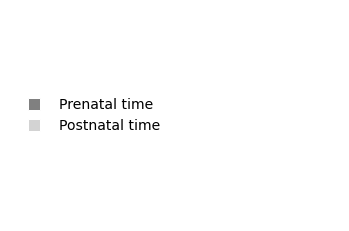

In [26]:
categories = ['Prenatal time','Postnatal time']
n_cats = len(categories)
labels = categories
colors_list = ['grey','lightgrey']
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=colors_list[j], markersize=12) for j in range(n_cats)]
plt.axis('off')
legend_title = ''
plt.legend(handles, labels, title=legend_title, loc='center left', ncol=1, fontsize=14, title_fontsize=15, frameon=False)
plt.savefig('plots/multiple_samples_cases_timings_biopsies_legend.svg', bbox_inches='tight',format='svg')

## Correlation common lineage with age at diagnosis

In [27]:
common_dict

{'pt18': 104,
 'pt4': 122,
 'pt6': 693,
 'PMC01': 483,
 'pt3': 507,
 'pt1': 1170,
 'pt5': 1691}

In [28]:
common_df = paired_df[['PATIENT','SAMPLE','TAB_BIOPSY']][paired_df['PATIENT'].isin(common_dict.keys())].drop_duplicates('PATIENT')
common_df['common_muts'] = common_df['PATIENT'].map(common_dict)
common_df

,PATIENT,SAMPLE,TAB_BIOPSY,common_muts
43,pt18,pt18_t1,0.01,104
26,pt4,pt4_t1,0.02,122
61,pt6,pt6_t1,1.60,693
0,PMC01,PMC01_t1,2.50,483
24,pt3,pt3_t1,4.79,507
21,pt1,pt1_t1,8.32,1170
28,pt5,pt5_t1,13.50,1691


In [29]:
from numpy.polynomial.polynomial import polyfit
from scipy import stats

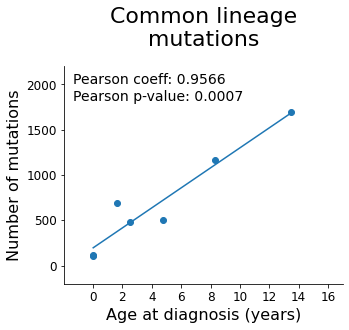

In [30]:
c = '#1f77b4'

plt.figure(figsize=(5,4))
x = common_df['TAB_BIOPSY']
y = common_df['common_muts']
plt.scatter(x=x,y=y,c=c)
b, m = polyfit(x, y, 1)
plt.plot(x, b + m * x, '-')

pearson_coef_pval = stats.pearsonr(x=x,y=y)
pearson_coef = round(pearson_coef_pval[0],4)
pearson_pval = round(pearson_coef_pval[1],4)

if pearson_pval == 0:
	pearson_pval = '<0.0001'

plt.text(x=0.15,y=0.82,s='Pearson coeff: '+str(pearson_coef),size=14,transform=plt.gcf().transFigure)
plt.text(x=0.15,y=0.76,s='Pearson p-value: '+str(pearson_pval),size=14,transform=plt.gcf().transFigure)

plt.xlim(-2,17)
plt.ylim(-200,2200)
plt.xticks(range(0,17,2),size=12)
plt.yticks(range(0,2001,500),size=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

title = 'Common lineage\nmutations'
plt.title(title,size=22,pad=20)
plt.ylabel('Number of mutations',size=16)
plt.xlabel('Age at diagnosis (years)',size=16)
plt.savefig('plots/correlation_common_lineage_age_diagnosis.svg', bbox_inches='tight',format='svg')
plt.show()